# Modèles de machine learning

Dans ce notebook, nous entraînons et évaluons plusieurs modèles de machine
learning pour la détection des faux avis Amazon.

Les textes prétraités sont représentés à l'aide de deux méthodes :
- Bag of Words ;
- TF-IDF.

Pour chaque représentation, deux modèles sont étudiés :
- la régression logistique ;
- le SVM linéaire.

Les meilleurs hyperparamètres sont sélectionnés à l'aide d'une validation
croisée stratifiée à cinq plis sur l'ensemble d'entraînement.

Les modèles retenus sont ensuite évalués sur l'ensemble de test à l'aide de
l'exactitude, de la précision, du rappel, du F1-score et de la PR-AUC.
Une matrice de confusion et une courbe précision-rappel sont également
présentées pour chaque configuration.

Enfin, les performances et les temps d'entraînement des différentes
configurations sont comparés.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
)
import time

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

## Chargement du dataset prétraité

Nous chargeons le dataset prétraité obtenu dans le notebook précédent. Il contient les avis originaux et prétraités, le statut d’achat vérifié, la longueur des avis ainsi que les labels textuel et numérique.

In [3]:
from pathlib import Path
import socket

HOSTNAME = socket.gethostname()

PROJECT_DIR = (
    Path.home() / "amazon_reviews_experimentation"
    if HOSTNAME == "cybernemo-main-worker-GPU1"
    else Path.cwd().parent
)

DATA_DIR = PROJECT_DIR / "data"
OUTPUTS_DIR = PROJECT_DIR / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

file_path = DATA_DIR / "amazon_reviews_preprocessed.csv"

print("Machine :", HOSTNAME)
print("Dossier du projet :", PROJECT_DIR)
print("Fichier utilisé :", file_path)

df = pd.read_csv(file_path)
df.head()

Machine : cybernemo-main-worker-GPU1
Dossier du projet : /home/siham/amazon_reviews_experimentation
Fichier utilisé : /home/siham/amazon_reviews_experimentation/data/amazon_reviews_preprocessed.csv


,DOC_ID,REVIEW_TEXT,preprocessed_text,VERIFIED_PURCHASE,review_word_count,LABEL,label_num
0,1,"When least you think so, this product will save the day. Just keep it around just in case you need it for something.",least think product save day keep around case need someth,N,23,fake,1
1,2,Lithium batteries are something new introduced in the market there average developing cost is relatively high but Stallion doesn't compromise on quality and provides us with the best at a low cost...,lithium batteri someth new introduc market averag develop cost rel high stallion compromis qualiti provid us best low cost br mani built technic assist act like sensor particular fort batteri keep...,Y,69,fake,1
2,3,I purchased this swing for my baby. She is 6 months now and has pretty much out grown it. It is very loud and doesn't swing very well. It is beautiful though. I love the colors and it has a lot of...,purchas swing babi 6 month pretti much grown loud swing well beauti though love color lot set think worth money,N,52,fake,1
3,4,I was looking for an inexpensive desk calcolatur and here it is. It works and does everything I need. Only issue is that it tilts slightly to one side so when I hit any keys it rocks a little bit....,look inexpens desk calcolatur work everyth need issu tilt slightli one side hit key rock littl bit big deal,N,44,fake,1
4,5,"I only use it twice a week and the results are great. I have used other teeth whitening solutions and most of them, for the same results I would have to use it at least three times a week. Will ke...",use twice week result great use teeth whiten solut result would use least three time week keep use potenc solut also techniqu tray keep everyth teeth mouth,N,66,fake,1


## Séparation des données en ensembles d'entraînement et de test

Les données sont divisées en un ensemble d’entraînement (80 %) et un ensemble de test (20 %). La séparation est stratifiée afin de conserver la répartition des classes. Les variables utilisées sont le texte prétraité, le statut d’achat vérifié et la longueur de l’avis.

In [4]:
X = df["preprocessed_text"]
y = df["label_num"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"Ensemble d'entraînement : {len(X_train)} avis")
print(f"Ensemble de test         : {len(X_test)} avis")

Ensemble d'entraînement : 16800 avis
Ensemble de test         : 4200 avis


## Définition de la validation croisée

Une validation croisée stratifiée à cinq plis est utilisée afin de conserver la proportion des deux classes dans chaque pli. Elle permet de sélectionner les meilleurs hyperparamètres à partir de l’ensemble d’entraînement.

In [5]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## Configuration expérimentale des modèles

Les quatre configurations évaluées dans ce notebook suivent le même protocole expérimental. Chaque modèle utilise uniquement le texte prétraité des avis, représenté à l’aide de Bag of Words ou de TF-IDF.

Pour chaque représentation textuelle, deux classifieurs sont étudiés : la régression logistique et le SVM linéaire. Pour chaque configuration, les hyperparamètres sont optimisés par validation croisée stratifiée à cinq plis (GridSearchCV). Le modèle retenu est celui obtenant le meilleur F1-score sur la classe positive (les faux avis), puis il est évalué sur le jeu de test indépendant.

## Régression logistique avec Bag of Words

In [6]:
# Pipeline de classification
pipeline_lr_bow = Pipeline([
    ("text", CountVectorizer(ngram_range=(1, 1))),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])
# Grille d'hyperparamètres
param_grid_lr_bow = {
    "text__min_df": [1, 2, 3, 5],
    "text__max_df": [0.80, 0.85, 0.90, 0.95, 1.0],
    "model__C": [0.01, 0.1, 1, 10, 100]
}
# Validation croisée
grid_lr_bow = GridSearchCV(
    estimator=pipeline_lr_bow,
    param_grid=param_grid_lr_bow,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
# Entraînement
start_time = time.perf_counter()
grid_lr_bow.fit(X_train, y_train)
training_time_lr_bow = time.perf_counter() - start_time
# Résultats
print("Meilleurs paramètres :", grid_lr_bow.best_params_)
print("Meilleur F1-score moyen en validation croisée :", grid_lr_bow.best_score_)
print(
    "Temps d’entraînement avec validation croisée :",
    f"{training_time_lr_bow / 60:.2f} minutes"
)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Meilleurs paramètres : {'model__C': 0.01, 'text__max_df': 0.8, 'text__min_df': 3}
Meilleur F1-score moyen en validation croisée : 0.6486201844987949
Temps d’entraînement avec validation croisée : 1.15 minutes


### Évaluation sur le jeu de test

In [7]:
# Meilleur modèle et prédictions
best_lr_bow = grid_lr_bow.best_estimator_
y_pred_lr_bow = best_lr_bow.predict(X_test)
y_score_lr_bow = best_lr_bow.predict_proba(X_test)[:, 1]
# Calcul des métriques
metrics_lr_bow = pd.DataFrame({
    "Métrique": ["Exactitude", "Précision", "Rappel", "F1-score", "PR-AUC"],
    "Valeur": [
        accuracy_score(y_test, y_pred_lr_bow),
        precision_score(y_test, y_pred_lr_bow),
        recall_score(y_test, y_pred_lr_bow),
        f1_score(y_test, y_pred_lr_bow),
        average_precision_score(y_test, y_score_lr_bow)
    ]
})
metrics_lr_bow["Valeur"] = metrics_lr_bow["Valeur"].round(4)
metrics_lr_bow

,Métrique,Valeur
0,Exactitude,0.6419
1,Précision,0.6329
2,Rappel,0.6757
3,F1-score,0.6536
4,PR-AUC,0.7033


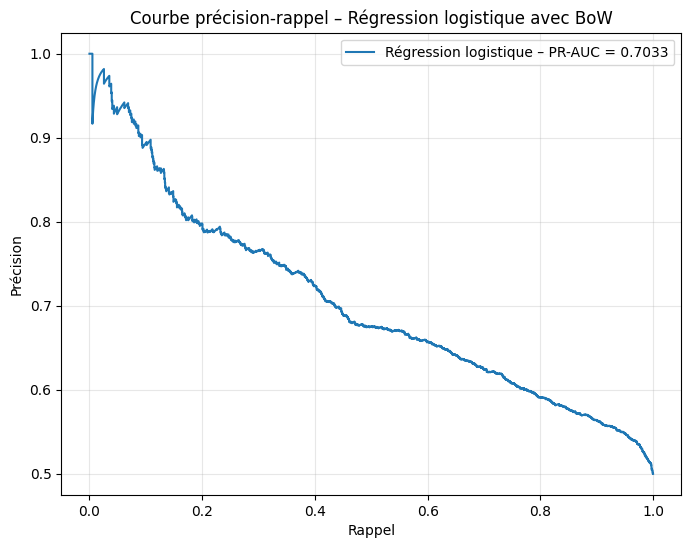

In [8]:
# Courbe précision-rappel
precision_lr_bow, recall_lr_bow, _ = precision_recall_curve(
    y_test, y_score_lr_bow
)
pr_auc_lr_bow = average_precision_score(y_test, y_score_lr_bow)

plt.figure(figsize=(8, 6))
plt.plot(
    recall_lr_bow,
    precision_lr_bow,
    label=f"Régression logistique – PR-AUC = {pr_auc_lr_bow:.4f}"
)
plt.xlabel("Rappel")
plt.ylabel("Précision")
plt.title("Courbe précision-rappel – Régression logistique avec BoW")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

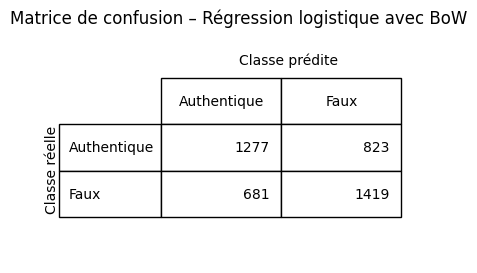

In [9]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_lr_bow)

fig, ax = plt.subplots(figsize=(5, 3))
ax.axis("off")
ax.table(
    cellText=cm,
    rowLabels=["Authentique", "Faux"],
    colLabels=["Authentique", "Faux"],
    bbox=[0.30, 0.20, 0.62, 0.60]
)
ax.text(0.50, 0.86, "Classe prédite")
ax.text(0, 0.23, "Classe réelle", rotation=90)
plt.title("Matrice de confusion – Régression logistique avec BoW")
plt.show()

## SVM linéaire avec Bag of Words

In [10]:
# Pipeline de classification
pipeline_svm_bow = Pipeline([
    ("text", CountVectorizer(ngram_range=(1, 1))),
    ("model", LinearSVC(max_iter=2000, random_state=42))
])
# Grille d'hyperparamètres
param_grid_svm_bow = {
    "text__min_df": [1, 2, 3, 5],
    "text__max_df": [0.80, 0.85, 0.90, 0.95, 1.0],
    "model__C": [0.01, 0.1, 1, 10, 100]
}
# Validation croisée
grid_svm_bow = GridSearchCV(
    estimator=pipeline_svm_bow,
    param_grid=param_grid_svm_bow,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
# Entraînement
start_time = time.perf_counter()
grid_svm_bow.fit(X_train, y_train)
training_time_svm_bow = time.perf_counter() - start_time
# Résultats
print("Meilleurs paramètres :", grid_svm_bow.best_params_)
print("Meilleur F1-score moyen en validation croisée :", grid_svm_bow.best_score_)
print(
    "Temps d’entraînement avec validation croisée :",
    f"{training_time_svm_bow / 60:.2f} minutes"
)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


/home/siham/amazon_reviews_env/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/siham/amazon_reviews_env/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/siham/amazon_reviews_env/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/siham/amazon_reviews_env/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/siham/amazon_reviews_env/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/siham/amazon_reviews_env/lib/python3.10/site-pack

Meilleurs paramètres : {'model__C': 0.01, 'text__max_df': 0.8, 'text__min_df': 1}
Meilleur F1-score moyen en validation croisée : 0.6491348456735049
Temps d’entraînement avec validation croisée : 10.51 minutes


### Évaluation sur le jeu de test

In [11]:
# Meilleur modèle et prédictions
best_svm_bow = grid_svm_bow.best_estimator_
y_pred_svm_bow = best_svm_bow.predict(X_test)
y_score_svm_bow = best_svm_bow.decision_function(X_test)
# Calcul des métriques
metrics_svm_bow = pd.DataFrame({
    "Métrique": ["Exactitude", "Précision", "Rappel", "F1-score", "PR-AUC"],
    "Valeur": [
        accuracy_score(y_test, y_pred_svm_bow),
        precision_score(y_test, y_pred_svm_bow),
        recall_score(y_test, y_pred_svm_bow),
        f1_score(y_test, y_pred_svm_bow),
        average_precision_score(y_test, y_score_svm_bow)
    ]
})
metrics_svm_bow["Valeur"] = metrics_svm_bow["Valeur"].round(4)
metrics_svm_bow

,Métrique,Valeur
0,Exactitude,0.6395
1,Précision,0.6319
2,Rappel,0.6686
3,F1-score,0.6497
4,PR-AUC,0.6995


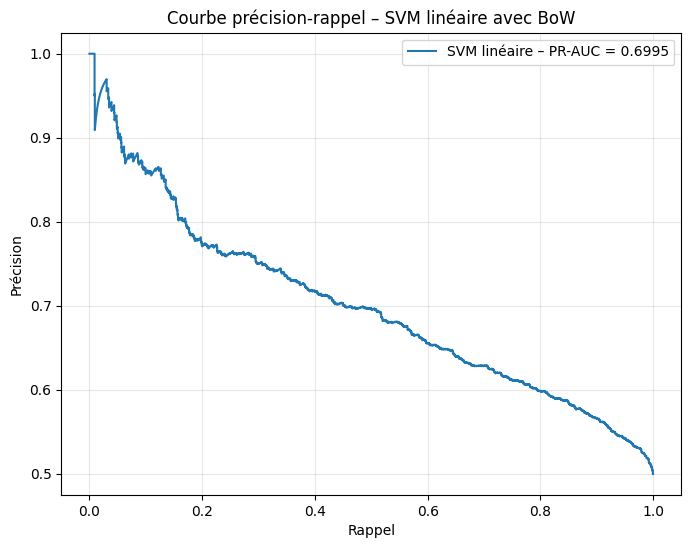

In [12]:
# Courbe précision-rappel
precision_svm_bow, recall_svm_bow, _ = precision_recall_curve(
    y_test, y_score_svm_bow
)
pr_auc_svm_bow = average_precision_score(y_test, y_score_svm_bow)

plt.figure(figsize=(8, 6))
plt.plot(
    recall_svm_bow,
    precision_svm_bow,
    label=f"SVM linéaire – PR-AUC = {pr_auc_svm_bow:.4f}"
)
plt.xlabel("Rappel")
plt.ylabel("Précision")
plt.title("Courbe précision-rappel – SVM linéaire avec BoW")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

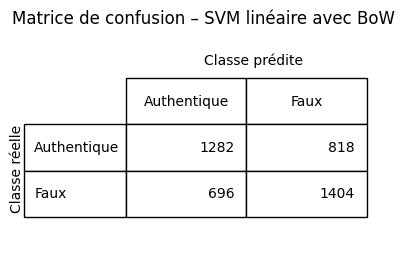

In [13]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_svm_bow)

fig, ax = plt.subplots(figsize=(5, 3))
ax.axis("off")
ax.table(
    cellText=cm,
    rowLabels=["Authentique", "Faux"],
    colLabels=["Authentique", "Faux"],
    bbox=[0.30, 0.20, 0.62, 0.60]
)
ax.text(0.50, 0.86, "Classe prédite")
ax.text(0, 0.23, "Classe réelle", rotation=90)
plt.title("Matrice de confusion – SVM linéaire avec BoW")
plt.show()

## Régression logistique avec TF-IDF

In [14]:
# Pipeline de classification
pipeline_lr_tfidf = Pipeline([
    ("text", TfidfVectorizer(ngram_range=(1, 1))),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])
# Grille d'hyperparamètres
param_grid_lr_tfidf = {
    "text__min_df": [1, 2, 3, 5],
    "text__max_df": [0.80, 0.85, 0.90, 0.95, 1.0],
    "model__C": [0.01, 0.1, 1, 10, 100]
}
# Validation croisée
grid_lr_tfidf = GridSearchCV(
    estimator=pipeline_lr_tfidf,
    param_grid=param_grid_lr_tfidf,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
# Entraînement
start_time = time.perf_counter()
grid_lr_tfidf.fit(X_train, y_train)
training_time_lr_tfidf = time.perf_counter() - start_time
# Résultats
print("Meilleurs paramètres :", grid_lr_tfidf.best_params_)
print(
    "Meilleur F1-score moyen en validation croisée :",
    grid_lr_tfidf.best_score_
)
print(
    "Temps d’entraînement avec validation croisée :",
    f"{training_time_lr_tfidf / 60:.2f} minutes"
)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Meilleurs paramètres : {'model__C': 1, 'text__max_df': 0.8, 'text__min_df': 3}
Meilleur F1-score moyen en validation croisée : 0.6451339900215312
Temps d’entraînement avec validation croisée : 0.56 minutes


### Évaluation sur le jeu de test

In [15]:
# Meilleur modèle et prédictions
best_lr_tfidf = grid_lr_tfidf.best_estimator_
y_pred_lr_tfidf = best_lr_tfidf.predict(X_test)
y_scores_lr_tfidf = best_lr_tfidf.predict_proba(X_test)[:, 1]
# Calcul des métriques
metrics_lr_tfidf = pd.DataFrame({
    "Métrique": ["Exactitude", "Précision", "Rappel", "F1-score", "PR-AUC"],
    "Valeur": [
        accuracy_score(y_test, y_pred_lr_tfidf),
        precision_score(y_test, y_pred_lr_tfidf),
        recall_score(y_test, y_pred_lr_tfidf),
        f1_score(y_test, y_pred_lr_tfidf),
        average_precision_score(y_test, y_scores_lr_tfidf)
    ]
})
metrics_lr_tfidf["Valeur"] = metrics_lr_tfidf["Valeur"].round(4)
metrics_lr_tfidf

,Métrique,Valeur
0,Exactitude,0.6486
1,Précision,0.6513
2,Rappel,0.6395
3,F1-score,0.6454
4,PR-AUC,0.7045


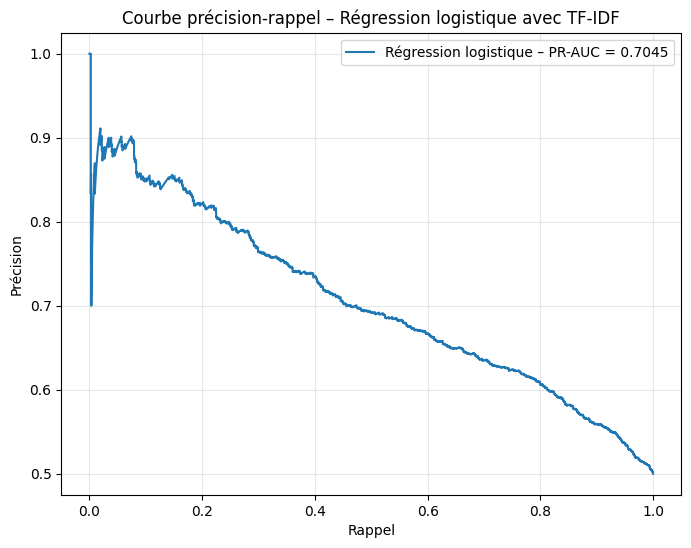

In [16]:
# Courbe précision-rappel
precision_lr_tfidf, recall_lr_tfidf, _ = precision_recall_curve(
    y_test, y_scores_lr_tfidf
)
pr_auc_lr_tfidf = average_precision_score(y_test, y_scores_lr_tfidf)

plt.figure(figsize=(8, 6))
plt.plot(
    recall_lr_tfidf,
    precision_lr_tfidf,
    label=f"Régression logistique – PR-AUC = {pr_auc_lr_tfidf:.4f}"
)
plt.xlabel("Rappel")
plt.ylabel("Précision")
plt.title("Courbe précision-rappel – Régression logistique avec TF-IDF")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

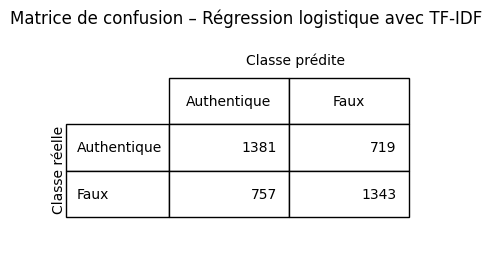

In [17]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_lr_tfidf)

fig, ax = plt.subplots(figsize=(5, 3))
ax.axis("off")
ax.table(
    cellText=cm,
    rowLabels=["Authentique", "Faux"],
    colLabels=["Authentique", "Faux"],
    bbox=[0.30, 0.20, 0.62, 0.60]
)
ax.text(0.50, 0.86, "Classe prédite")
ax.text(0, 0.23, "Classe réelle", rotation=90)
plt.title("Matrice de confusion – Régression logistique avec TF-IDF")
plt.show()

## SVM linéaire avec TF-IDF

In [18]:
# Pipeline de classification
pipeline_svm_tfidf = Pipeline([
    ("text", TfidfVectorizer(ngram_range=(1, 1))),
    ("model", LinearSVC(max_iter=2000, random_state=42))
])
# Grille d'hyperparamètres
param_grid_svm_tfidf = {
    "text__min_df": [1, 2, 3, 5],
    "text__max_df": [0.80, 0.85, 0.90, 0.95, 1.0],
    "model__C": [0.01, 0.1, 1, 10, 100]
}
# Validation croisée
grid_svm_tfidf = GridSearchCV(
    estimator=pipeline_svm_tfidf,
    param_grid=param_grid_svm_tfidf,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
# Entraînement
start_time = time.perf_counter()
grid_svm_tfidf.fit(X_train, y_train)
training_time_svm_tfidf = time.perf_counter() - start_time
# Résultats
print("Meilleurs paramètres :", grid_svm_tfidf.best_params_)
print(
    "Meilleur F1-score moyen en validation croisée :",
    grid_svm_tfidf.best_score_
)
print(
    "Temps d’entraînement avec validation croisée :",
    f"{training_time_svm_tfidf / 60:.2f} minutes"
)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


/home/siham/amazon_reviews_env/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/siham/amazon_reviews_env/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/siham/amazon_reviews_env/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/siham/amazon_reviews_env/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/siham/amazon_reviews_env/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/siham/amazon_reviews_env/lib/python3.10/site-pack

Meilleurs paramètres : {'model__C': 0.1, 'text__max_df': 0.8, 'text__min_df': 3}
Meilleur F1-score moyen en validation croisée : 0.6442326265933571
Temps d’entraînement avec validation croisée : 1.20 minutes


### Évaluation sur le jeu de test

In [19]:
# Meilleur modèle et prédictions
best_svm_tfidf = grid_svm_tfidf.best_estimator_
y_pred_svm_tfidf = best_svm_tfidf.predict(X_test)
y_scores_svm_tfidf = best_svm_tfidf.decision_function(X_test)
# Calcul des métriques
metrics_svm_tfidf = pd.DataFrame({
    "Métrique": ["Exactitude", "Précision", "Rappel", "F1-score", "PR-AUC"],
    "Valeur": [
        accuracy_score(y_test, y_pred_svm_tfidf),
        precision_score(y_test, y_pred_svm_tfidf),
        recall_score(y_test, y_pred_svm_tfidf),
        f1_score(y_test, y_pred_svm_tfidf),
        average_precision_score(y_test, y_scores_svm_tfidf)
    ]
})
metrics_svm_tfidf["Valeur"] = metrics_svm_tfidf["Valeur"].round(4)
metrics_svm_tfidf

,Métrique,Valeur
0,Exactitude,0.6467
1,Précision,0.6495
2,Rappel,0.6371
3,F1-score,0.6433
4,PR-AUC,0.7042


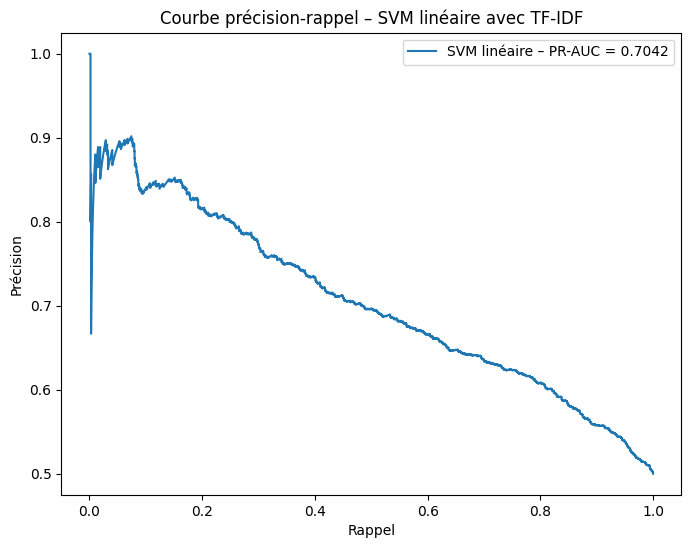

In [20]:
# Courbe précision-rappel
precision_svm_tfidf, recall_svm_tfidf, _ = precision_recall_curve(
    y_test, y_scores_svm_tfidf
)
pr_auc_svm_tfidf = average_precision_score(y_test, y_scores_svm_tfidf)

plt.figure(figsize=(8, 6))
plt.plot(
    recall_svm_tfidf,
    precision_svm_tfidf,
    label=f"SVM linéaire – PR-AUC = {pr_auc_svm_tfidf:.4f}"
)
plt.xlabel("Rappel")
plt.ylabel("Précision")
plt.title("Courbe précision-rappel – SVM linéaire avec TF-IDF")
plt.legend()
plt.show()

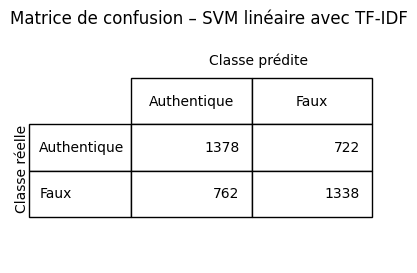

In [21]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_svm_tfidf)

fig, ax = plt.subplots(figsize=(5, 3))
ax.axis("off")
ax.table(
    cellText=cm,
    rowLabels=["Authentique", "Faux"],
    colLabels=["Authentique", "Faux"],
    bbox=[0.30, 0.20, 0.62, 0.60]
)
ax.text(0.50, 0.86, "Classe prédite")
ax.text(0, 0.23, "Classe réelle", rotation=90)
plt.title("Matrice de confusion – SVM linéaire avec TF-IDF")
plt.show()

## Temps d’entraînement avec validation croisée

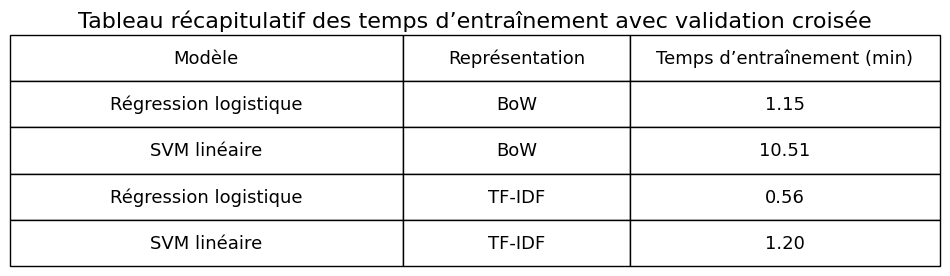

In [22]:
# Tableau récapitulatif des temps d'entraînement
training_times_ml = pd.DataFrame({
    "Modèle": [
        "Régression logistique",
        "SVM linéaire",
        "Régression logistique",
        "SVM linéaire"
    ],
    "Représentation": ["BoW", "BoW", "TF-IDF", "TF-IDF"],
    "Temps d’entraînement (min)": [
        training_time_lr_bow / 60,
        training_time_svm_bow / 60,
        training_time_lr_tfidf / 60,
        training_time_svm_tfidf / 60
    ]
})
training_times_ml["Temps d’entraînement (min)"] = (
    training_times_ml["Temps d’entraînement (min)"]
    .map(lambda x: f"{x:.2f}")
)
training_times_ml

fig, ax = plt.subplots(figsize=(12, 3))
ax.axis("off")
table = ax.table(
    cellText=training_times_ml.values,
    colLabels=training_times_ml.columns,
    cellLoc="center",
    bbox=[0, 0, 1, 1],
    colWidths=[0.38, 0.22, 0.30]
)
table.auto_set_font_size(False)
table.set_fontsize(13)
plt.title(
    "Tableau récapitulatif des temps d’entraînement avec validation croisée",
    fontsize=16
)
plt.show()

## Comparaison des modèles

Cette section compare les performances des quatre configurations évaluées. Les résultats permettent d'analyser l'influence de la représentation textuelle (BoW ou TF-IDF) ainsi que du modèle de classification (régression logistique ou SVM linéaire) sur la détection des faux avis.

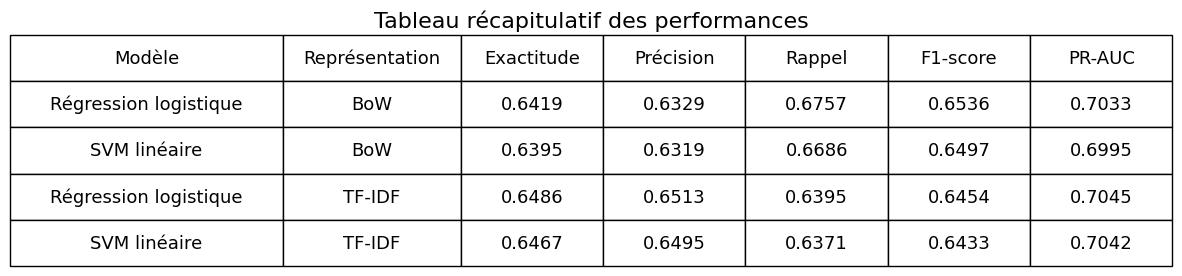

In [23]:
# Tableau récapitulatif des performances
results = pd.DataFrame({
    "Modèle": [
        "Régression logistique",
        "SVM linéaire",
        "Régression logistique",
        "SVM linéaire"
    ],
    "Représentation": ["BoW", "BoW", "TF-IDF", "TF-IDF"],
    "Exactitude": [
        metrics_lr_bow.loc[0, "Valeur"],
        metrics_svm_bow.loc[0, "Valeur"],
        metrics_lr_tfidf.loc[0, "Valeur"],
        metrics_svm_tfidf.loc[0, "Valeur"]
    ],
    "Précision": [
        metrics_lr_bow.loc[1, "Valeur"],
        metrics_svm_bow.loc[1, "Valeur"],
        metrics_lr_tfidf.loc[1, "Valeur"],
        metrics_svm_tfidf.loc[1, "Valeur"]
    ],
    "Rappel": [
        metrics_lr_bow.loc[2, "Valeur"],
        metrics_svm_bow.loc[2, "Valeur"],
        metrics_lr_tfidf.loc[2, "Valeur"],
        metrics_svm_tfidf.loc[2, "Valeur"]
    ],
    "F1-score": [
        metrics_lr_bow.loc[3, "Valeur"],
        metrics_svm_bow.loc[3, "Valeur"],
        metrics_lr_tfidf.loc[3, "Valeur"],
        metrics_svm_tfidf.loc[3, "Valeur"]
    ],
    "PR-AUC": [
        metrics_lr_bow.loc[4, "Valeur"],
        metrics_svm_bow.loc[4, "Valeur"],
        metrics_lr_tfidf.loc[4, "Valeur"],
        metrics_svm_tfidf.loc[4, "Valeur"]
    ]
})

fig, ax = plt.subplots(figsize=(15, 3))
ax.axis("off")
table = ax.table(
    cellText=results.values,
    colLabels=results.columns,
    cellLoc="center",
    bbox=[0, 0, 1, 1],
    colWidths=[0.23, 0.15, 0.12, 0.12, 0.12, 0.12, 0.12]
)
table.auto_set_font_size(False)
table.set_fontsize(13)
plt.title("Tableau récapitulatif des performances", fontsize=16)
plt.show()

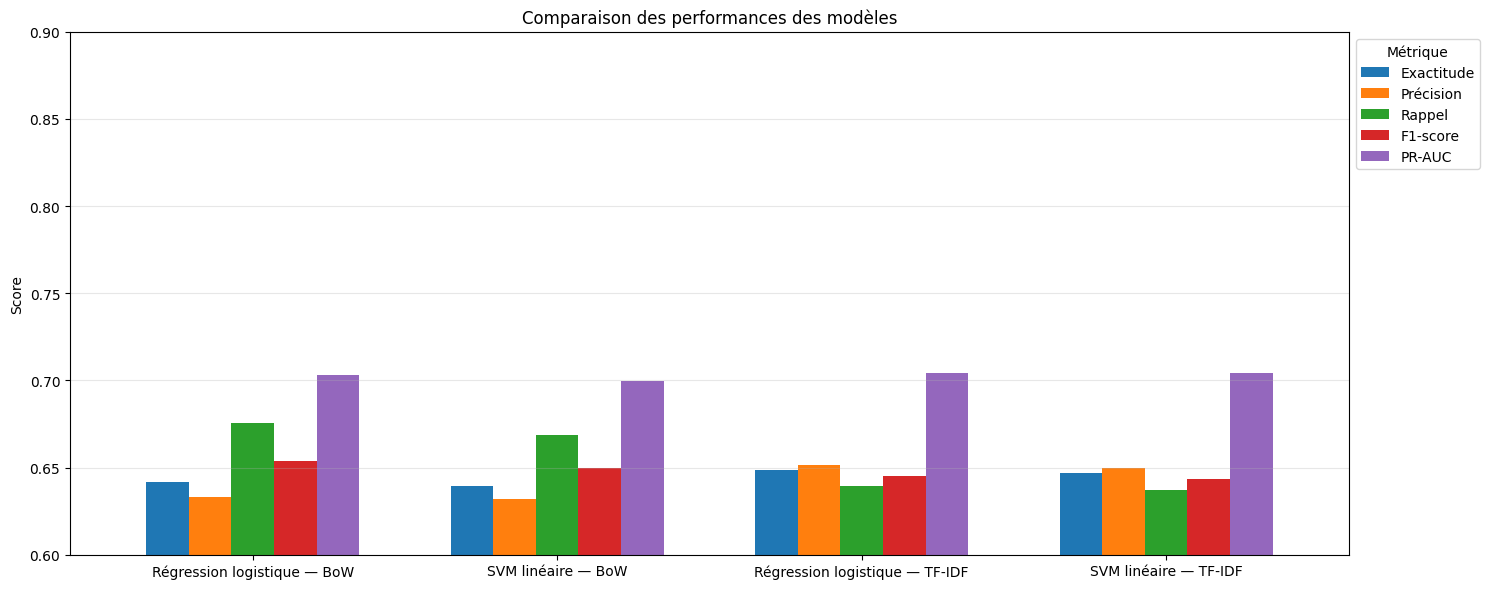

In [27]:
# Comparaison graphique des performances
comparison_results = results.copy()
comparison_results["Configuration"] = (
    comparison_results["Modèle"] + " — " + comparison_results["Représentation"]
)
metrics_to_plot = ["Exactitude", "Précision", "Rappel", "F1-score", "PR-AUC"]

comparison_results.set_index("Configuration")[metrics_to_plot].plot(
    kind="bar",
    figsize=(15, 6),
    width=0.7
)
plt.title("Comparaison des performances des modèles")
plt.xlabel("")
plt.ylabel("Score")
plt.ylim(0.6, 0.9)
plt.xticks(rotation=0, ha="center")
plt.legend(title="Métrique", bbox_to_anchor=(1, 1), loc="upper left")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

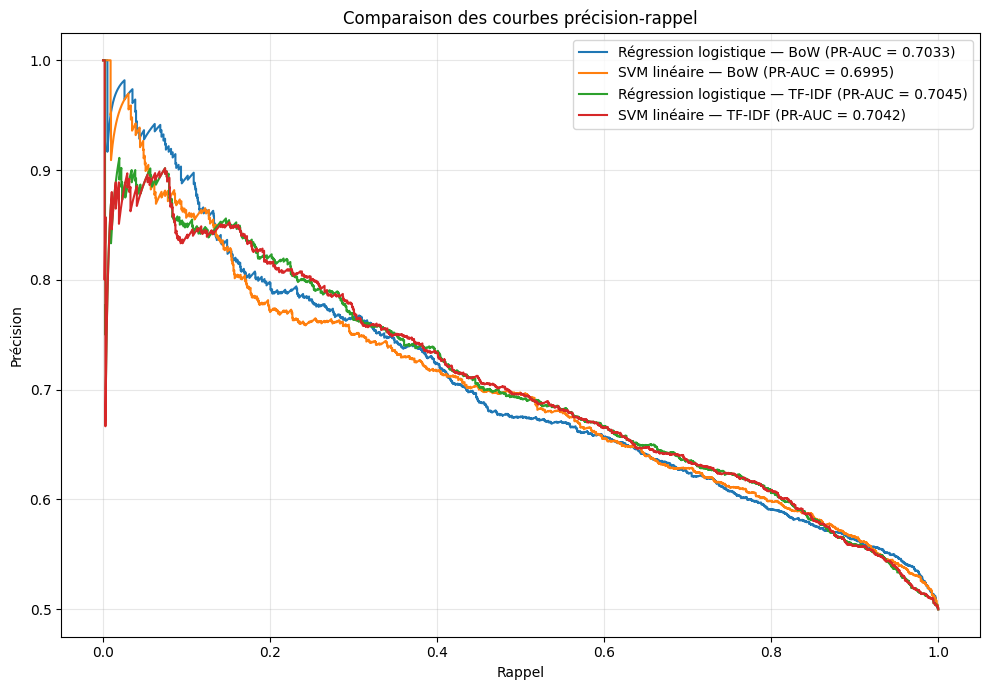

In [25]:
# Comparaison des courbes précision-rappel
plt.figure(figsize=(10, 7))
plt.plot(
    recall_lr_bow, precision_lr_bow,
    label=f"Régression logistique — BoW (PR-AUC = {pr_auc_lr_bow:.4f})"
)
plt.plot(
    recall_svm_bow, precision_svm_bow,
    label=f"SVM linéaire — BoW (PR-AUC = {pr_auc_svm_bow:.4f})"
)
plt.plot(
    recall_lr_tfidf, precision_lr_tfidf,
    label=f"Régression logistique — TF-IDF (PR-AUC = {pr_auc_lr_tfidf:.4f})"
)
plt.plot(
    recall_svm_tfidf, precision_svm_tfidf,
    label=f"SVM linéaire — TF-IDF (PR-AUC = {pr_auc_svm_tfidf:.4f})"
)
plt.xlabel("Rappel")
plt.ylabel("Précision")
plt.title("Comparaison des courbes précision-rappel")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Les quatre configurations obtiennent des performances relativement proches. La régression logistique associée à Bag of Words présente le meilleur rappel (0,6757) et le meilleur F1-score (0,6536), tandis que les configurations utilisant TF-IDF obtiennent une PR-AUC légèrement supérieure. Compte tenu de l’objectif de détection des faux avis, correspondant à la classe positive, la régression logistique associée à Bag of Words est retenue parmi les modèles de machine learning. Elle offre le meilleur compromis pour identifier les faux avis, tout en conservant une PR-AUC proche de celles des autres configurations. Ces résultats serviront de référence pour la comparaison avec les modèles fondés sur les Transformers présentés dans le notebook suivant.